In [ ]:
!pip install openpyxl

1. Master Dataset Yükleniyor ve Akşam Verisi Ayıklanıyor...

🚀 AKŞAM VARDİYASI İÇİN TARGET ENCODER + HİPERPARAMETRE AVI
 -> Eğitim (Train) Bitiş: 2026-06-21
 -> Test Seti Aralığı: 2026-06-22 / 2026-06-28

[ENCODER] Target Encoder (Kategorik Dönüştürücü) Eğitiliyor...
✅ Target Encoder başarıyla '01_target_encoder.pkl' olarak kaydedildi.

[AKŞAM] XGBoost Genişletilmiş Hiperparametre Avı Başlıyor...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

[AKŞAM - ŞAMPİYON PARAMETRELER]: {'subsample': 0.6, 'n_estimators': 700, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

--------------------------------------------------
🏆 AKŞAM MODELİ BAŞARI RAPORU (TEST SETİ)
--------------------------------------------------
MAE: 598.88 Desi
RMSE: 1150.01 Desi
R2 Skoru: 0.9605
WAPE (Hata Oranı): %18.49
--------------------------------------------------
✅ AKŞAM Modeli PKL olarak kaydedildi.
✅ Test sonuçları 'Test_Sonuclari_Gercek_Vs_Tahmin_AKSAM.xlsx' dosyasına kaydedildi.


<Figure size 1000x600 with 0 Axes>

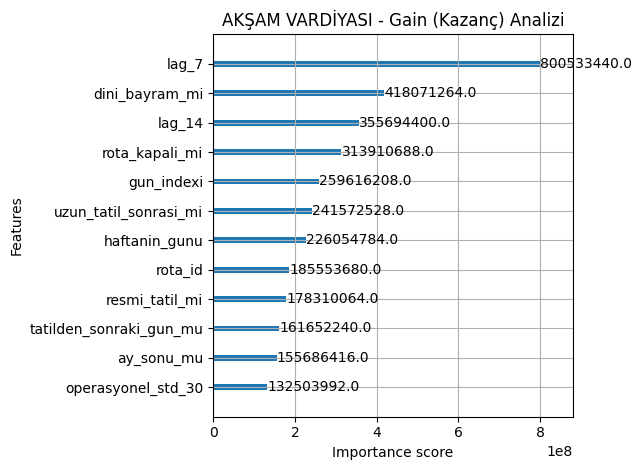


🚀 Akşam modeli, Target Encoder ve derin optimizasyon ile kusursuz şekilde tamamlandı.


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import warnings

# Gereksiz uyarıları gizle
warnings.filterwarnings('ignore')

print("1. Master Dataset Yükleniyor ve Akşam Verisi Ayıklanıyor...")
dosya_yolu = '/content/Master_Dataset_Tum_Turkiye.xlsx'
df_master = pd.read_excel(dosya_yolu)

# Zaman serisi olduğu için veriyi mutlaka tarihe ve vardiyaya göre sıralamalıyız!
df_master['tarih'] = pd.to_datetime(df_master['tarih'])
df_master = df_master.sort_values(by=['tarih', 'sabah_mi']).reset_index(drop=True)

# Eğitimde asla olmaması gereken çöp sütunlar
cop_sutunlar = [
    'tarih', 'gun_ismi', 'talep_tamamlanma_saati', 'cikis', 'varis',
    'gunluk_desi_hesabi', 'talep_id', 'sentetik_mi','cikis_makro_hacim','varis_makro_hacim',
    'anomali_suphesi','varis_doygunluk_orani','cikis_bagimlilik_orani','son_ayni_vardiya_acik_desi',
    '_yeni_eklendi','lag_7_resmi_tatil_mi','lag_7_dini_bayram_mi','lag_14_resmi_tatil_mi',
    'lag_14_dini_bayram_mi','gecmis_kör_mü','tarihsel_gun_ortalamasi', 'sabah_mi'
]

# ---------------------------------------------------------
# SADECE AKŞAM VERİSİNİ FİLTRELE (sabah_mi == 0)
# ---------------------------------------------------------
df_aksam = df_master[df_master['sabah_mi'] == 0].copy()

print(f"\n{'='*60}")
print(f"🚀 AKŞAM VARDİYASI İÇİN TARGET ENCODER + HİPERPARAMETRE AVI")
print(f"{'='*60}")

# 1. Train/Test Split
test_gun_sayisi = 7
max_tarih = df_aksam['tarih'].max()
kesim_tarihi = max_tarih - pd.Timedelta(days=test_gun_sayisi)

print(f" -> Eğitim (Train) Bitiş: {kesim_tarihi:%Y-%m-%d}")
print(f" -> Test Seti Aralığı: {(kesim_tarihi + pd.Timedelta(days=1)):%Y-%m-%d} / {max_tarih:%Y-%m-%d}")

df_train = df_aksam[df_aksam['tarih'] <= kesim_tarihi].copy()
df_test = df_aksam[df_aksam['tarih'] > kesim_tarihi].copy()

X_train = df_train.drop(columns=['toplam_desi'] + cop_sutunlar, errors='ignore')
y_train = df_train['toplam_desi']

X_test = df_test.drop(columns=['toplam_desi'] + cop_sutunlar, errors='ignore')
y_test = df_test['toplam_desi']

# ---------------------------------------------------------
# TARGET ENCODER ENTEGRASYONU
# ---------------------------------------------------------
print("\n[ENCODER] Target Encoder (Kategorik Dönüştürücü) Eğitiliyor...")
try:
    from category_encoders import TargetEncoder
except ImportError:
    raise SystemExit("❌ Lütfen terminale 'pip install category_encoders' yazarak kütüphaneyi yükleyin!")

# Rota ID gibi kategorik kolonları Target Encoder ile sayısal ortalamalara dönüştürüyoruz
kategorik_kolonlar = ['rota_id'] if 'rota_id' in X_train.columns else []

target_encoder = TargetEncoder(cols=kategorik_kolonlar, smoothing=10.0)

# Veri sızıntısını (data leakage) önlemek için train'e fit edip, test'e transform yapıyoruz
X_train_encoded = target_encoder.fit_transform(X_train, y_train)
X_test_encoded = target_encoder.transform(X_test)

# Target Encoder dosyası olarak kaydediliyor
joblib.dump(target_encoder, '01_target_encoder.pkl')
print("✅ Target Encoder başarıyla '01_target_encoder.pkl' olarak kaydedildi.")

# ---------------------------------------------------------
# XTREME GRADIENT BOOSTING (XGBOOST) OPTİMİZASYONU
# ---------------------------------------------------------
print("\n[AKŞAM] XGBoost Genişletilmiş Hiperparametre Avı Başlıyor...")
model = xgb.XGBRegressor(
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 700, 1000],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Artık encoded edilmiş train verisiyle fit ediyoruz
random_search.fit(X_train_encoded, y_train)
best_model = random_search.best_estimator_

print(f"\n[AKŞAM - ŞAMPİYON PARAMETRELER]: {random_search.best_params_}")

# 2. Test Seti Üzerinde Tahmin (Encoded test verisi kullanılıyor)
y_pred = best_model.predict(X_test_encoded)
y_pred_yuvarlanmis = np.clip(np.round(y_pred), a_min=0, a_max=None).astype(int)

# 3. Metrikler
mae = mean_absolute_error(y_test, y_pred_yuvarlanmis)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_yuvarlanmis))
r2 = r2_score(y_test, y_pred_yuvarlanmis)
wape = np.sum(np.abs(y_test - y_pred_yuvarlanmis)) / (np.sum(y_test) + 1e-9)

print("\n" + "-" * 50)
print(f"🏆 AKŞAM MODELİ BAŞARI RAPORU (TEST SETİ)")
print("-" * 50)
print(f"MAE: {mae:.2f} Desi")
print(f"RMSE: {rmse:.2f} Desi")
print(f"R2 Skoru: {r2:.4f}")
print(f"WAPE (Hata Oranı): %{wape * 100:.2f}")
print("-" * 50)

# 4. Şampiyon Modeli Kaydetme
joblib.dump(best_model, 'xgboost_lojistik_modeli_AKSAM.pkl')
print("✅ AKŞAM Modeli PKL olarak kaydedildi.")

# 5. Sonuçları Excel'e Dökme
df_test_sonuc = df_test.copy()
df_test_sonuc['Tahmin_Edilen_Desi'] = y_pred_yuvarlanmis
df_test_sonuc['Mutlak_Hata'] = (df_test_sonuc['Tahmin_Edilen_Desi'] - df_test_sonuc['toplam_desi']).abs()

cikti_excel = 'Test_Sonuclari_Gercek_Vs_Tahmin_AKSAM.xlsx'
df_test_sonuc.to_excel(cikti_excel, index=False)
print(f"✅ Test sonuçları '{cikti_excel}' dosyasına kaydedildi.")

# 6. Gain (Kazanç) Analizi Grafiği
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_model, importance_type='gain', max_num_features=12, title='AKŞAM VARDİYASI - Gain (Kazanç) Analizi')
plt.tight_layout()
plt.show()

print("\n🚀 Akşam modeli, Target Encoder ve derin optimizasyon ile kusursuz şekilde tamamlandı.")

In [ ]:
from google.colab import drive
import shutil

# 1. Drive'ını Colab'e bağla (Çıkan uyarıya izin ver)
drive.mount('/content/drive')

# 2. Dosyayı Drive'ına kopyala
# '01_target_encoder.pkl' yerine kendi dosyanın tam adını yaz
kaynak_dosya = '/content/xgboost_lojistik_modeli_AKSAM.pkl'
hedef_dosya = '/content/drive/MyDrive/xgboost_lojistik_modeli_AKSAM.pkl'

shutil.copy(kaynak_dosya, hedef_dosya)
print("✅ Dosya başarıyla Google Drive'a kopyalandı! Artık Drive'ına girip indirebilirsin.")

Mounted at /content/drive
✅ Dosya başarıyla Google Drive'a kopyalandı! Artık Drive'ına girip indirebilirsin.


In [45]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings('ignore')

def recursive_tahmin_pipeline_encoder_li(hazir_veri_dosyasi, encoder_dosyasi, model_dosyasi, cikti_dosyasi, baslangic, bitis):
    """
    Target Encoder ve XGBoost'u birlikte kullanan, rota kimliklerini akıllıca
    harmanlayarak günden güne (recursive) tahmin yapan kusursuz mimari.
    """
    print(f"[{model_dosyasi}] ve [{encoder_dosyasi}] yükleniyor...")
    model = joblib.load(model_dosyasi)
    target_encoder = joblib.load(encoder_dosyasi)

    print("Ana veri yükleniyor...")
    df = pd.read_excel(hazir_veri_dosyasi)
    df['tarih'] = pd.to_datetime(df['tarih'])
    df = df.sort_values(by=['rota_id', 'sabah_mi', 'tarih']).reset_index(drop=True)

    baslangic_dt = pd.to_datetime(baslangic)
    bitis_dt = pd.to_datetime(bitis)
    tarihler = pd.date_range(start=baslangic_dt, end=bitis_dt)

    # Modelin ve Encoder'ın görmesini istemediğimiz meta sütunlar
    cop_sutunlar = [
        'tarih', 'gun_ismi', 'talep_tamamlanma_saati', 'cikis', 'varis',
        'gunluk_desi_hesabi', 'talep_id', 'sentetik_mi', 'cikis_makro_hacim', 'varis_makro_hacim',
        'anomali_suphesi', 'varis_doygunluk_orani', 'cikis_bagimlilik_orani', 'son_ayni_vardiya_acik_desi',
        '_yeni_eklendi', 'lag_7_resmi_tatil_mi', 'lag_7_dini_bayram_mi', 'lag_14_resmi_tatil_mi',
        'lag_14_dini_bayram_mi', 'gecmis_kör_mü', 'gecmisi_kor_mu', 'tarihsel_gun_ortalamasi', 'sabah_mi'
    ]

    print("\n🚀 RECURSIVE (Target Encoder'lı) Tahminleme Başlıyor...")

    for suanki_tarih in tarihler:
        print(f"-> {suanki_tarih.strftime('%Y-%m-%d')} tahmin ediliyor ve dinamik özellikler güncelleniyor...")

        # A. Dinamik hesaplama maskesi
        mask_guncel = df['tarih'] <= suanki_tarih

        # B. Hareketli ortalama ve standart sapmaları bugüne kadar güncelle
        df.loc[mask_guncel, 'son_7_gun_hareketli_ortalama'] = (
            df[mask_guncel].groupby(['rota_id', 'sabah_mi'])['toplam_desi']
            .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
        )

        df.loc[mask_guncel, 'operasyonel_std_7'] = (
            df[mask_guncel].groupby(['rota_id', 'sabah_mi'])['toplam_desi']
            .transform(lambda x: x.shift(1).rolling(window=7, min_periods=2).std())
        ).fillna(0)

        df.loc[mask_guncel, 'operasyonel_std_30'] = (
            df[mask_guncel].groupby(['rota_id', 'sabah_mi'])['toplam_desi']
            .transform(lambda x: x.shift(1).rolling(window=30, min_periods=2).std())
        ).fillna(0)

        # C. Bugünü ve akşamı filtrele
        mask_bugun_aksam = (df['tarih'] == suanki_tarih) & (df['sabah_mi'] == 0)
        df_bugun = df[mask_bugun_aksam].copy()

        if df_bugun.empty:
            continue

        # D. Ham matrisi hazırla
        X_test_ham = df_bugun.drop(columns=['toplam_desi'] + cop_sutunlar, errors='ignore')

        # E. MÜHENDİSLİK DÜZELTMESİ: Sütun sırasını ve yapısını model/encoder ile %100 eşitle
        if hasattr(model, 'feature_names_in_'):
            expected_features = model.feature_names_in_
            X_test = X_test_ham.reindex(columns=expected_features, fill_value=0)
        else:
            X_test = X_test_ham

        # F. Target Encoder ile Rota ID'leri dönüştür (Matrisin bütünlüğünü bozmadan)
        # category_encoders tüm tabloyu alıp içerideki kategorik sütunları (rota_id) encode eder
        X_test_encoded = target_encoder.transform(X_test)

        # G. Tahmin Et
        tahminler = model.predict(X_test_encoded)
        tahminler_yuvarlanmis = np.clip(np.round(tahminler), a_min=0, a_max=None).astype(int)

        # H. Enjeksiyon
        df.loc[mask_bugun_aksam, 'toplam_desi'] = tahminler_yuvarlanmis

    # 3. Sonucu Dışarı Aktar
    print("\nVeri Dışa Aktarılıyor...")
    mask_gelecek = (df['tarih'] >= baslangic_dt) & (df['tarih'] <= bitis_dt) & (df['sabah_mi'] == 0)
    df_cikti = df[mask_gelecek][['tarih', 'gun_ismi', 'rota_id', 'talep_tamamlanma_saati', 'toplam_desi']].copy()

    df_cikti.rename(columns={'toplam_desi': 'Tahmin_Edilen_Desi'}, inplace=True)
    df_cikti = df_cikti.sort_values(by=['tarih', 'rota_id'])

    df_cikti.to_excel(cikti_dosyasi, index=False)
    print(f"✅ Target Encoder'lı Kusursuz Operasyon Tamamlandı! Rapor: {cikti_dosyasi}\n")

if __name__ == "__main__":
    recursive_tahmin_pipeline_encoder_li(
        hazir_veri_dosyasi='/content/Master_Dataset_Tum_Özellikler_Hazir_V2.xlsx',
        encoder_dosyasi='/content/01_target_encoder.pkl',
        model_dosyasi='/content/xgboost_lojistik_modeli_AKSAM.pkl',
        cikti_dosyasi='29Haziran_5Temmuz_AKSAM_Encoderli_Recursive_Rapor.xlsx',
        baslangic='2026-06-29',
        bitis='2026-07-05'
    )

[/content/xgboost_lojistik_modeli_AKSAM.pkl] ve [/content/01_target_encoder.pkl] yükleniyor...
Ana veri yükleniyor...

🚀 RECURSIVE (Target Encoder'lı) Tahminleme Başlıyor...
-> 2026-06-29 tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-06-30 tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-01 tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-02 tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-03 tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-04 tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-05 tahmin ediliyor ve dinamik özellikler güncelleniyor...

Veri Dışa Aktarılıyor...
✅ Çıkış ve Varis Sütunlu Operasyon Tamamlandı! Rapor: 29Haziran_5Temmuz_AKSAM_CikisVarisli_Rapor.xlsx



SABAH MODELİ EĞİTİMİ


1. Master Dataset Yükleniyor ve Sabah Verisi Ayıklanıyor...

🚀 SABAH VARDİYASI İÇİN TARGET ENCODER + HİPERPARAMETRE AVI
 -> Eğitim (Train) Bitiş: 2026-06-21
 -> Test Seti Aralığı: 2026-06-22 / 2026-06-28

[ENCODER] Target Encoder (Kategorik Dönüştürücü) Sabah Verisi İçin Eğitiliyor...
✅ Sabah Target Encoder başarıyla '01_target_encoder_SABAH.pkl' olarak kaydedildi.

[SABAH] XGBoost Genişletilmiş Hiperparametre Avı Başlıyor...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

[SABAH - ŞAMPİYON PARAMETRELER]: {'subsample': 0.6, 'n_estimators': 700, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

--------------------------------------------------
🏆 SABAH MODELİ BAŞARI RAPORU (TEST SETİ)
--------------------------------------------------
MAE: 235.68 Desi
RMSE: 903.12 Desi
R2 Skoru: 0.6051
WAPE (Hata Oranı): %53.41
--------------------------------------------------
✅ SABAH Modeli PKL olarak kaydedildi.
✅ Test sonuçları 'Test_Sonuclari_Gercek_Vs_Tahmin_SABAH.xlsx

<Figure size 1000x600 with 0 Axes>

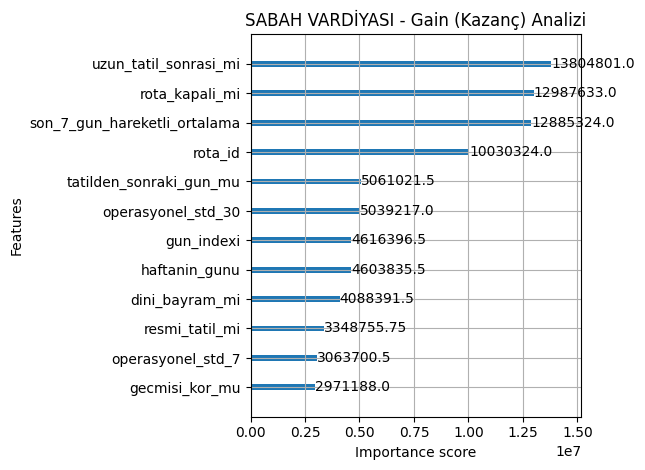


🚀 Sabah modeli, Target Encoder ve derin optimizasyon ile kusursuz şekilde tamamlandı.


In [39]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import warnings

# Gereksiz uyarıları gizle
warnings.filterwarnings('ignore')

print("1. Master Dataset Yükleniyor ve Sabah Verisi Ayıklanıyor...")
dosya_yolu = '/content/Master_Dataset_Tum_Turkiye.xlsx'
df_master = pd.read_excel(dosya_yolu)

# Zaman serisi olduğu için veriyi mutlaka tarihe ve vardiyaya göre sıralamalıyız!
df_master['tarih'] = pd.to_datetime(df_master['tarih'])
df_master = df_master.sort_values(by=['tarih', 'sabah_mi']).reset_index(drop=True)

# Eğitimde asla olmaması gereken çöp sütunlar
cop_sutunlar = [
    'tarih', 'gun_ismi', 'talep_tamamlanma_saati', 'cikis', 'varis',
    'gunluk_desi_hesabi', 'talep_id', 'sentetik_mi','cikis_makro_hacim','varis_makro_hacim',
    'anomali_suphesi','varis_doygunluk_orani','cikis_bagimlilik_orani','son_ayni_vardiya_acik_desi',
    '_yeni_eklendi','lag_7_resmi_tatil_mi','lag_7_dini_bayram_mi','lag_14_resmi_tatil_mi',
    'lag_14_dini_bayram_mi','gecmis_kör_mü','tarihsel_gun_ortalamasi', 'sabah_mi'
]

# ---------------------------------------------------------
# SADECE SABAH VERİSİNİ FİLTRELE (sabah_mi == 1)
# ---------------------------------------------------------
df_sabah = df_master[df_master['sabah_mi'] == 1].copy()

print(f"\n{'='*60}")
print(f"🚀 SABAH VARDİYASI İÇİN TARGET ENCODER + HİPERPARAMETRE AVI")
print(f"{'='*60}")

# 1. Train/Test Split
test_gun_sayisi = 7
max_tarih = df_sabah['tarih'].max()
kesim_tarihi = max_tarih - pd.Timedelta(days=test_gun_sayisi)

print(f" -> Eğitim (Train) Bitiş: {kesim_tarihi:%Y-%m-%d}")
print(f" -> Test Seti Aralığı: {(kesim_tarihi + pd.Timedelta(days=1)):%Y-%m-%d} / {max_tarih:%Y-%m-%d}")

df_train = df_sabah[df_sabah['tarih'] <= kesim_tarihi].copy()
df_test = df_sabah[df_sabah['tarih'] > kesim_tarihi].copy()

X_train = df_train.drop(columns=['toplam_desi'] + cop_sutunlar, errors='ignore')
y_train = df_train['toplam_desi']

X_test = df_test.drop(columns=['toplam_desi'] + cop_sutunlar, errors='ignore')
y_test = df_test['toplam_desi']

# ---------------------------------------------------------
# TARGET ENCODER ENTEGRASYONU (SABAH İÇİN ÖZEL)
# ---------------------------------------------------------
print("\n[ENCODER] Target Encoder (Kategorik Dönüştürücü) Sabah Verisi İçin Eğitiliyor...")
try:
    from category_encoders import TargetEncoder
except ImportError:
    raise SystemExit("❌ Lütfen terminale 'pip install category_encoders' yazarak kütüphaneyi yükleyin!")

# Rota ID gibi kategorik kolonları Target Encoder ile sayısal ortalamalara dönüştürüyoruz
kategorik_kolonlar = ['rota_id'] if 'rota_id' in X_train.columns else []

target_encoder_sabah = TargetEncoder(cols=kategorik_kolonlar, smoothing=10.0)

# Veri sızıntısını (data leakage) önlemek için train'e fit edip, test'e transform yapıyoruz
X_train_encoded = target_encoder_sabah.fit_transform(X_train, y_train)
X_test_encoded = target_encoder_sabah.transform(X_test)

# Sabah Target Encoder dosyası olarak kaydediliyor
joblib.dump(target_encoder_sabah, '01_target_encoder_SABAH.pkl')
print("✅ Sabah Target Encoder başarıyla '01_target_encoder_SABAH.pkl' olarak kaydedildi.")

# ---------------------------------------------------------
# XTREME GRADIENT BOOSTING (XGBOOST) OPTİMİZASYONU - SABAH
# ---------------------------------------------------------
print("\n[SABAH] XGBoost Genişletilmiş Hiperparametre Avı Başlıyor...")
model = xgb.XGBRegressor(
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [300, 500, 700, 1000],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Artık encoded edilmiş sabah train verisiyle fit ediyoruz
random_search.fit(X_train_encoded, y_train)
best_model_sabah = random_search.best_estimator_

print(f"\n[SABAH - ŞAMPİYON PARAMETRELER]: {random_search.best_params_}")

# 2. Test Seti Üzerinde Tahmin (Encoded test verisi kullanılıyor)
y_pred = best_model_sabah.predict(X_test_encoded)
y_pred_yuvarlanmis = np.clip(np.round(y_pred), a_min=0, a_max=None).astype(int)

# 3. Metrikler
mae = mean_absolute_error(y_test, y_pred_yuvarlanmis)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_yuvarlanmis))
r2 = r2_score(y_test, y_pred_yuvarlanmis)
wape = np.sum(np.abs(y_test - y_pred_yuvarlanmis)) / (np.sum(y_test) + 1e-9)

print("\n" + "-" * 50)
print(f"🏆 SABAH MODELİ BAŞARI RAPORU (TEST SETİ)")
print("-" * 50)
print(f"MAE: {mae:.2f} Desi")
print(f"RMSE: {rmse:.2f} Desi")
print(f"R2 Skoru: {r2:.4f}")
print(f"WAPE (Hata Oranı): %{wape * 100:.2f}")
print("-" * 50)

# 4. Şampiyon Sabah Modelini Kaydetme
joblib.dump(best_model_sabah, 'xgboost_lojistik_modeli_SABAH.pkl')
print("✅ SABAH Modeli PKL olarak kaydedildi.")

# 5. Sonuçları Excel'e Dökme
df_test_sonuc = df_test.copy()
df_test_sonuc['Tahmin_Edilen_Desi'] = y_pred_yuvarlanmis
df_test_sonuc['Mutlak_Hata'] = (df_test_sonuc['Tahmin_Edilen_Desi'] - df_test_sonuc['toplam_desi']).abs()

cikti_excel = 'Test_Sonuclari_Gercek_Vs_Tahmin_SABAH.xlsx'
df_test_sonuc.to_excel(cikti_excel, index=False)
print(f"✅ Test sonuçları '{cikti_excel}' dosyasına kaydedildi.")

# 6. Gain (Kazanç) Analizi Grafiği
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_model_sabah, importance_type='gain', max_num_features=12, title='SABAH VARDİYASI - Gain (Kazanç) Analizi')
plt.tight_layout()
plt.show()

print("\n🚀 Sabah modeli, Target Encoder ve derin optimizasyon ile kusursuz şekilde tamamlandı.")

In [40]:
from google.colab import drive
import shutil

# 1. Drive'ını Colab'e bağla (Çıkan uyarıya izin ver)
drive.mount('/content/drive')

# 2. Dosyayı Drive'ına kopyala
# '01_target_encoder.pkl' yerine kendi dosyanın tam adını yaz
kaynak_dosya = '/content/xgboost_lojistik_modeli_SABAH.pkl'
hedef_dosya = '/content/drive/MyDrive/xgboost_lojistik_modeli_SABAH.pkl'

shutil.copy(kaynak_dosya, hedef_dosya)
print("✅ Dosya başarıyla Google Drive'a kopyalandı! Artık Drive'ına girip indirebilirsin.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dosya başarıyla Google Drive'a kopyalandı! Artık Drive'ına girip indirebilirsin.


In [41]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings('ignore')

def recursive_tahmin_pipeline_sabah(hazir_veri_dosyasi, encoder_dosyasi, model_dosyasi, cikti_dosyasi, baslangic, bitis):
    """
    SABAH VARDİYASI İÇİN: Target Encoder ve XGBoost'u birlikte kullanan,
    rota kimliklerini harmanlayarak günden güne (recursive) tahmin yapan mimari.
    """
    print(f"[{model_dosyasi}] ve [{encoder_dosyasi}] yükleniyor...")
    model = joblib.load(model_dosyasi)
    target_encoder = joblib.load(encoder_dosyasi)

    print("Ana veri yükleniyor...")
    df = pd.read_excel(hazir_veri_dosyasi)
    df['tarih'] = pd.to_datetime(df['tarih'])
    df = df.sort_values(by=['rota_id', 'sabah_mi', 'tarih']).reset_index(drop=True)

    baslangic_dt = pd.to_datetime(baslangic)
    bitis_dt = pd.to_datetime(bitis)
    tarihler = pd.date_range(start=baslangic_dt, end=bitis_dt)

    # Modelin ve Encoder'ın görmesini istemediğimiz meta sütunlar
    cop_sutunlar = [
        'tarih', 'gun_ismi', 'talep_tamamlanma_saati', 'cikis', 'varis',
        'gunluk_desi_hesabi', 'talep_id', 'sentetik_mi', 'cikis_makro_hacim', 'varis_makro_hacim',
        'anomali_suphesi', 'varis_doygunluk_orani', 'cikis_bagimlilik_orani', 'son_ayni_vardiya_acik_desi',
        '_yeni_eklendi', 'lag_7_resmi_tatil_mi', 'lag_7_dini_bayram_mi', 'lag_14_resmi_tatil_mi',
        'lag_14_dini_bayram_mi', 'gecmis_kör_mü', 'gecmisi_kor_mu', 'tarihsel_gun_ortalamasi', 'sabah_mi'
    ]

    print("\n🚀 SABAH RECURSIVE (Target Encoder'lı) Tahminleme Başlıyor...")

    for suanki_tarih in tarihler:
        print(f"-> {suanki_tarih.strftime('%Y-%m-%d')} (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...")

        # A. Dinamik hesaplama maskesi
        mask_guncel = df['tarih'] <= suanki_tarih

        # B. Hareketli ortalama ve standart sapmaları bugüne kadar güncelle (Sabah vardiyasına göre)
        df.loc[mask_guncel, 'son_7_gun_hareketli_ortalama'] = (
            df[mask_guncel].groupby(['rota_id', 'sabah_mi'])['toplam_desi']
            .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
        )

        df.loc[mask_guncel, 'operasyonel_std_7'] = (
            df[mask_guncel].groupby(['rota_id', 'sabah_mi'])['toplam_desi']
            .transform(lambda x: x.shift(1).rolling(window=7, min_periods=2).std())
        ).fillna(0)

        df.loc[mask_guncel, 'operasyonel_std_30'] = (
            df[mask_guncel].groupby(['rota_id', 'sabah_mi'])['toplam_desi']
            .transform(lambda x: x.shift(1).rolling(window=30, min_periods=2).std())
        ).fillna(0)

        # C. Bugünü ve SABAHI filtrele (sabah_mi == 1)
        mask_bugun_sabah = (df['tarih'] == suanki_tarih) & (df['sabah_mi'] == 1)
        df_bugun = df[mask_bugun_sabah].copy()

        if df_bugun.empty:
            continue

        # D. Ham matrisi hazırla
        X_test_ham = df_bugun.drop(columns=['toplam_desi'] + cop_sutunlar, errors='ignore')

        # E. Sütun sırasını ve yapısını model/encoder ile %100 eşitle
        if hasattr(model, 'feature_names_in_'):
            expected_features = model.feature_names_in_
            X_test = X_test_ham.reindex(columns=expected_features, fill_value=0)
        else:
            X_test = X_test_ham

        # F. Target Encoder ile Rota ID'leri dönüştür
        X_test_encoded = target_encoder.transform(X_test)

        # G. Tahmin Et
        tahminler = model.predict(X_test_encoded)
        tahminler_yuvarlanmis = np.clip(np.round(tahminler), a_min=0, a_max=None).astype(int)

        # H. Enjeksiyon (Sabah sütununa yaz)
        df.loc[mask_bugun_sabah, 'toplam_desi'] = tahminler_yuvarlanmis

    # 3. Sonucu Dışarı Aktar
    print("\nVeri Dışa Aktarılıyor...")
    mask_gelecek = (df['tarih'] >= baslangic_dt) & (df['tarih'] <= bitis_dt) & (df['sabah_mi'] == 1)
    df_cikti = df[mask_gelecek][['tarih', 'gun_ismi', 'rota_id', 'talep_tamamlanma_saati', 'toplam_desi']].copy()

    df_cikti.rename(columns={'toplam_desi': 'Tahmin_Edilen_Desi'}, inplace=True)
    df_cikti = df_cikti.sort_values(by=['tarih', 'rota_id'])

    df_cikti.to_excel(cikti_dosyasi, index=False)
    print(f"✅ Sabah Target Encoder'lı Operasyon Tamamlandı! Rapor: {cikti_dosyasi}\n")

if __name__ == "__main__":
    recursive_tahmin_pipeline_sabah(
        hazir_veri_dosyasi='/content/Master_Dataset_Tum_Özellikler_Hazir_V2.xlsx',
        encoder_dosyasi='/content/01_target_encoder_SABAH.pkl',
        model_dosyasi='/content/xgboost_lojistik_modeli_SABAH.pkl',
        cikti_dosyasi='29Haziran_5Temmuz_SABAH_Encoderli_Recursive_Rapor.xlsx',
        baslangic='2026-06-29',
        bitis='2026-07-05'
    )

[/content/xgboost_lojistik_modeli_SABAH.pkl] ve [/content/01_target_encoder_SABAH.pkl] yükleniyor...
Ana veri yükleniyor...

🚀 SABAH RECURSIVE (Target Encoder'lı) Tahminleme Başlıyor...
-> 2026-06-29 (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-06-30 (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-01 (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-02 (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-03 (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-04 (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...
-> 2026-07-05 (SABAH) tahmin ediliyor ve dinamik özellikler güncelleniyor...

Veri Dışa Aktarılıyor...
✅ Sabah Target Encoder'lı Operasyon Tamamlandı! Rapor: 29Haziran_5Temmuz_SABAH_Encoderli_Recursive_Rapor.xlsx

